In [1]:
import xarray as xr
import analyze_precip as ap
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import seaborn as sns
import importlib
import cftime
from scipy.stats import skew
import datetime
import os
import fnmatch
import time

import track_TCs
import TC_analysis

## Auxiliary functions

### get LMI dfs

In [2]:
def risplit_dfs(track_df):
    #track_df = pd.read_pickle(filename)
    
    # calculate 24-hour acceleration
    track_df['acceleration_24'] = track_df.groupby('storm_id')['max_wind'].diff(periods=4)
    
    # identify RI/non-RI storm ids
    catch_df = track_df[track_df['acceleration_24'] > 18] # RI: +18 m/s within 24 hours
    ristorms = catch_df['storm_id'].unique()
    
    nonstorms = []
    for k in track_df['storm_id'].unique():
        if k in ristorms:
            continue
        else:
            nonstorms.append(k)

    assert len(track_df['storm_id'].unique()) == len(ristorms) + len(nonstorms), f"error with ristorm and non-ristorm length"
    
    # create RI/non-RI storm dataframes
    ri_df = track_df[track_df['storm_id'].isin(ristorms)]
    ri_df['max_wind_kts'] = ri_df['max_wind']*1.94384
    
    nonri_df = track_df[track_df['storm_id'].isin(nonstorms)]
    nonri_df['max_wind_kts'] = nonri_df['max_wind']*1.94384

    return ri_df, nonri_df

In [3]:
def get_LMI_dfs(track_df):
    ri_df, nonri_df = risplit_dfs(track_df)

    lmi_ri_df = ri_df.groupby('storm_id')['max_wind'].max().to_frame()
    lmi_nonri_df = nonri_df.groupby('storm_id')['max_wind'].max().to_frame()

    return lmi_ri_df, lmi_nonri_df

### gabe's cmap function

In [4]:
def get_colormap_samples(number_of_samples: int,
                         colormap_name: str='viridis',
                         interval_minimum: int|float=0.1,
                         interval_maximum: int|float=0.9) -> list[str]:
    
    ''' Sample discrete points from a colormap. '''

    # Ensure colormap is valid
    assert colormap_name in matplotlib.colormaps, f'Colormap {colormap_name} not in matplotlib.colormaps.'

    # Get array points for sampling
    sampling_points = np.linspace(interval_minimum, interval_maximum, number_of_samples)
    # Get colors from colormaps using sampling points
    colors = matplotlib.colormaps[colormap_name](sampling_points)
    
    return colors

In [5]:
number_of_samples = 15
colormap_name = 'Spectral_r'
colors = get_colormap_samples(number_of_samples, colormap_name)

### SST functions

In [ ]:
forcing_SSTs = {'NW': 'NONWARMING_SST_PATH',
                'GW': 'WARMING_SST_PATH'}

In [ ]:
# get time index of certain year(s) from SST_ds
# end_year = exclusive
def year2index(GW, start_year, end_year):
    forcing_SSTs = {'NW': 'NONWARMING_SST_PATH',
                    'GW': 'WARMING_SST_PATH'}

    idx = []
    if GW == 1:
        path = forcing_SSTs['GW']
        SST_ds = xr.open_dataset(path)
    elif GW == 0:
    #if GW == 0 and start_year == 1871: #prev commented out next 2 lines while keeping SST_ds as parameter
        path = forcing_SSTs['NW']
        SST_ds = xr.open_dataset(path)
        new_index = SST_ds.indexes['time'].to_datetimeindex()
        SST_ds['time'] = new_index
    
    times = pd.Series(SST_ds['time'])
    
    for year in range(start_year, end_year):
        idx.extend(list(times.dt.year[times.dt.year == year].index))
    return SST_ds, idx

In [8]:
# calculate decadal average sst
'''
lat_filter = slice of desired latitudes OR 'all' (default all latitudes)
year_filter = desired year ranges OR 'all' (default all years)
'''

def SST_decmeans(GW, lat_filter, year_filter):
    if GW == 1:
        path = forcing_SSTs['GW']
    elif GW == 0:
        path = forcing_SSTs['NW']
    SST_ds = xr.open_dataset(path)

    # apply year filter
    if year_filter != 'all':
        decades = np.arange(1901, 1951, 10)
    else:
        decades = np.arange(1871, 2021, 10)
    yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
        
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    
    i = 0
    for decade in yearranges:
        print(f"decade: {decade}")
        #print(SST_ds)
            
        st_time = time.time()
        
        start_year = int(decade[0])
        end_year = int(decade[-1])
        idx = year2index(GW, SST_ds, start_year, end_year)
        assert len(idx) == 12*(end_year-start_year)
        
        filtered_ds = SST_ds.isel(time=idx)
        # apply latitude filter
        if lat_filter != 'all':
            filtered_ds = xr.concat([filtered_ds.sel(lat=slice(-30,-10)), filtered_ds.sel(lat=slice(10,30))], dim="lat")
            #print(f"{filtered_ds['lat'].values}")
        decade_means[i] = filtered_ds['sst'].mean()
        
        print(f"decmean: {decade_means[i]}")
        i += 1
        
        end_time = time.time()
        #print(f"time elapsed for load(): {end_time-st_time}")
        print("")

    return decade_means

In [ ]:
'''
lat_filter = 'tropics' OR 'all' (default all latitudes)
year_filter = desired year ranges OR 'all' (default all years)
'''

def PI_decmeans(GW, lat_filter, year_filter):
    # set parameters
    if GW == 1:
        fenum = 9
    elif GW == 0:
        fenum = 11
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)]
    
    # apply year filter
    if year_filter != 'all':
        yearranges = year_filter
    else:
        decades = np.arange(1871, 2021, 10)
        yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
      
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    
    i = 0
    for decade in yearranges:
        print(f"decade: {decade}")
        st_time = time.time()
        
        decmean = 0
        for ennum in ennums:
            print(f"ennum: {ennum}")
            for year in decade:
                if year == 2020 and GW == 1:
                    continue
                pathname = PIpathname(GW, ennum, year)
                filtered_ds = xr.open_dataset(pathname)
                # apply latitude filter
                if lat_filter != 'all':
                    filtered_ds = filtered_ds.sel(grid_yt=slice(10,30))
                    print(f"{filtered_ds['grid_yt'].values}")
                decmean += filtered_ds['vmax'].mean()
                
                if year == 1871:
                    print(f"{pathname}")
        
        # calculate decade mean
        if year == 2020 and GW == 1:
            decmean = decmean / ((len(yearranges[0])-1)*len(ennums))
        else:
            decmean = decmean / (len(yearranges[0])*len(ennums))
        
        decade_means[i] = decmean
        print(f"decmean: {decmean}")
        i += 1
        
        end_time = time.time()
        print(f"time elapsed for load(): {end_time-st_time}")
        print("")
        
    return decade_means

In [ ]:
# PI netcdf naming: "YYYY0101.atmos_month.PI.nc"

def PIpathname(GW, ennum, year, climVar):
    if GW == 1:
        basePath = "WARMING_MODEL_PATH"
    elif GW == 0:
        basePath = "NONWARMING_MODEL_PATH"

    PI_yearpath = f"{basePath}/TCIplev/{year}0101.atmos_month.PI.nc"

    #VI, Vshear, chi, chi_sb, eta, H, GPI
    if climVar == 'chi':
        VI_yearpath = f"{basePath}/TCIplev/{year}0101.atmos_month.chi.nc"
    elif climVar == 'chi_sb':
        VI_yearpath = f"{basePath}/TCIplev/{year}0101.atmos_month.chi_sb.nc"
    elif climVar == 'Vshear':
        VI_yearpath = f"{basePath}/TCIplev/{year}0101.atmos_month.Vshear.nc"
    else:
        VI_yearpath = f"{basePath}/TCIplev/{year}0101.atmos_month.VI.nc"
    
    return PI_yearpath, VI_yearpath

### plotting function

In [11]:
def plot_xrda(dataarray, title, robust, vmin: int=None, vmax: int=None, cmap: str="viridis"):
    fig, ax = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    
    if robust == 0:
        dataarray.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax) # robust=True will get reduce noise beyond stdev thresh
    elif robust == 1:
        dataarray.plot(ax=ax, transform=ccrs.PlateCarree(), robust=True, cmap=cmap, vmin=vmin, vmax=vmax) # robust=True will get reduce noise beyond stdev thresh
    ax.gridlines(draw_labels=['bottom', 'left'], ls=':')
    ax.coastlines()
    ax.set_title(f"{title}")

### aux: basin, density, Hseason filter

In [ ]:
def basinfilter(xarray, basin2mask):
    basinmask_path = "/projects/GEOCLIM/gr7610/tools/basin_mask.nc"
    basin_ds = xr.open_dataset(basinmask_path).load()
    
    if basin2mask == 'tropics': # latitude filter
        xarray = xr.concat([xarray.sel(lat=slice(-30,-10)), xarray.sel(lat=slice(10,30))], dim="lat")
    elif basin2mask != 'global':
        x = basin_ds.where(basin_ds[basin2mask] == 1, drop=True)[basin2mask] #stores basin coordinates

        maxlat = max(x['grid_yt']).item()
        minlat = min(x['grid_yt']).item()
        maxlon = max(x['grid_xt']).item()
        minlon = min(x['grid_xt']).item()

        if 'lon' in xarray.coords:
            xarray = xarray.where((xarray['lat'] >= minlat) & (xarray['lat'] <= maxlat), drop=True) #filter latitude
            xarray = xarray.where((xarray['lon'] >= minlon) & (xarray['lon'] <= maxlon), drop=True) #filter longitude
        else:
            print(f"Coordinates not found in xarray.")
        
    return xarray

In [ ]:
def TCdensity(GW, year_range, PIx_da):
    global TCdensity_xr
    
    # get experiment names and dictionary of xarrays
    from pathlib import Path
    
    experiment_path = '/projects/GEOCLIM/gr7610/MODEL_OUT/AM2.5C360'
    
    experiments = []
    if GW == 1:
        target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
        for file in target_files:
            experiments.append(str(file)[-29:])
    elif GW == 0:
        target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
        for file in target_files:
            experiments.append(str(file)[-39:])

    # experiments already gathered in prev cell
    model_name = 'AM2.5C360'
    experiment_name = experiments
        #en06-en10 (experiments[1-2, 5-7]) do not work for some reason -> all GW = 0
    
    # return dictionary[model_name][experiment_name] of TC density
    TCdensity = TC_analysis.TC_density(model_names=model_name, experiment_names=experiment_name, year_range=year_range)
    
    listof_TCdensities = []
    
    # combine all ensemble density outputs
    for exp in experiment_name:
        TMP = TCdensity[model_name][exp]
        
        # convert dictionary to dataframe with same dims for xarray
        TCdensity_xr = xr.DataArray(data=TMP.values,
                                       coords={'lat': (['lat'], TMP.index),
                                               'lon': (['lon'], TMP.columns)},
                                       dims=['lat', 'lon'])
        
        TCdensity_xr = TCdensity_xr.sel(lat=slice(PIx_da.lat.min(), PIx_da.lat.max()))
        # Interpolate to GCM native resolution
        TCdensity_xr = TCdensity_xr.interp(lon=PIx_da.lon, lat=PIx_da.lat).fillna(0)
        listof_TCdensities.append(TCdensity_xr) # append xarray to list for concatenation
    
    TCdensity_xr = xr.concat(listof_TCdensities, dim='exp')
    density = TCdensity_xr.mean(dim='exp')
    
    #normDensity = ((TCdensity_xr - TCdensity_xr.min()) / (TCdensity_xr.max() - TCdensity_xr.min())) #normalize (0,1) for matrix multiplication
    #normDensity = normDensity+1 #normalize (1,2) for matrix multiplication

    return density

In [ ]:
'''
filter that returns dataarray with only points from hurricane season

NH: August-October
SH: April-December
'''
def hurricane_season(xarray):
    north_da = xarray.where((xarray['lat'] > 0) & (xarray['time'].dt.month >= 8) & (xarray['time'].dt.month <= 10), drop=True)
    south_da = xarray.where((xarray['lat'] < 0) & (xarray['time'].dt.month >= 4) & (xarray['time'].dt.month <= 12), drop=True)
    filtered = xr.concat([north_da, south_da], dim="time")

    #plot_xrda(filtered.mean(dim='time'), "hurricane season filter: filtered", 1) # print for debugging
    
    return filtered

### PI functions

In [15]:
def realign_sstda(filtered_ds, sst_ds, plottimeJ, plottimeN):
    filtered_da = filtered_ds['To'].sel(time=plottimeJ)
    sst_da = sst_ds['sst'].sel(time=plottimeN, method='nearest')
    
    # rename coordinate values
    filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"})
    
    # realign output & SST datasets
    sst_da = sst_da.interp_like(filtered_da, method='nearest')

    return sst_da

In [ ]:
'''
get xr DataArray for given climate variable (climVar), year, model (GW or rmWarming), and basin

basin2mask = {global, tropics, NA, WP, EP, SP}
climVar = {PI, PIprox, PIT, enthalpy, VI, Vshear, chi, chi_sb, SST}
'''
def get_PI_components(GW, year, basin2mask, climVar):
    global filtered_ds
    if GW == 1:
        fenum = 9
    elif GW == 0:
        fenum = 11
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)]
    
    # 1. get PI, VI Dataset from all ennums for year
    collect_fds = []
    
    if climVar in ['PI', 'PIprox', 'PIT', 'enthalpy', 'SST']: # set which pathname to take from PIpathname
        whichPath = 0
    elif climVar in ['VI', 'Vshear', 'chi', 'chi_sb']:
        whichPath = 1
        
    for ennum in ennums:
        pathTuple = PIpathname(GW, ennum, year, climVar) # returns PI_yearpath, VI_yearpath
        collect_fds.append(xr.open_dataset(pathTuple[whichPath]))
    filtered_ds = xr.concat(collect_fds, dim='time')
        # filtered_ds represents climate Dataset (from which specific climVar DataArray will be selected)
    
    # 2. get SST Dataset for year (process separately because both PI and SST Datasets needed for PIT)
    sst_ds, idx = year2index(GW, year, year+1)
    assert len(idx) == 12
    sst_ds = sst_ds.isel(time=idx)

    # 2b. standardize coords
    filtered_ds = filtered_ds.rename({"grid_xt": "lon", "grid_yt": "lat"}) # rename coords to match
    
    # 3. apply basin filter
    filtered_ds = basinfilter(filtered_ds, basin2mask)
    sst_ds = basinfilter(sst_ds, basin2mask)
    
    # 3a. get climVar data array
    if climVar in ['PI', 'PIprox', 'enthalpy']: # get DataArray from filtered_ds
        param = 'vmax'
    elif climVar == 'PIT':
        param = 'To'
    else:
        param = climVar

    filtered_da = filtered_ds[param] #To, vmax, VI
    sst_da = sst_ds['sst']

    # 3b. standardize resolution between filtered_ds and sst_ds
    if GW == 0:
        convtimes = [datetime.datetime(time.year, time.month, time.day, time.hour, time.minute, time.second) for time in filtered_da['time'].values]
    elif GW == 1:
        convtimes = [datetime.datetime(time.year, time.month, time.day, time.hour, time.minute, time.second) for time in filtered_da['time'].values]
    sst_da = sst_da.interp(lat=filtered_da['lat'], lon=filtered_da['lon'], time=convtimes, method='linear', kwargs={"fill_value": "extrapolate"})
        
    return filtered_da, sst_da

In [17]:
'''
calculate PI given filtered_da, sst_da
'''
def calc_PI(filtered_da, sst_da):
    s = sst_da.mean(dim="time")
    #s = sst_da
    to = filtered_da.mean(dim="time")
    pi_T = (s-to)/to #PI squared
    #pi = np.sqrt(pi2)

    return pi_T

'''
calculate PI~ given local sst_da and tropics sst_da
PI~ = local SST - mean tropics SST
'''
def calc_PIprox(local_sst_da, tropics_sst_da):
    piprox = local_sst_da-(tropics_sst_da.mean(dim="time"))
    return piprox

In [18]:
'''
decadal avg of monthly PI calculations

basin2mask = {all, tropics, basin abbbrevation}
stat = {mean, spvar (spatial variance)}
climVar = {PI, PIprox, PIT, enthalpy, VI, Vshear, chi, chi_sb}
isWeighted = {0, 1} -> TC density weighting
inHSeason = {0,1} -> calculate for hurricane season only
'''
def get_manualPI(GW, basin2mask, stat, climVar, isWeighted, inHSeason):
    # global for debugging
    global pi
    global pi_T
    global TCp
    global pi_cosW
    global pi_cosW_t
    global avg_calcPI
    global decade_means
    global dict_calcPI
    
    decades = np.arange(1871, 2021, 10)
    yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
    
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    yearly_stat = [] # store average stat per year for distribution plots
    
    if GW == 1:
        fenum = 9
    elif GW == 0:
        fenum = 11
    ennums = [f"0{j}" if j < 10 else f"{j}" for j in range(6,fenum)]
    
    dict_calcPI = {}

    i = 0
    print(f"GW={GW} for {climVar} {stat}")
    for decade in yearranges:
        st_time = time.time()
        
        for year in decade:
            if year == 2020 and GW == 1: # no data for this year
                continue
            
            # 4. get climVar data (pi variable)
            if climVar == 'PIprox':
                tr_filtered_da, tropics_sst_da = get_PI_components(GW, year, 'tropics', climVar)
                pi = calc_PIprox(sst_da, tropics_sst_da)
            else:
                filtered_da, sst_da = get_PI_components(GW, year, basin2mask, climVar)
            
                # pi_T and enthalpy require different calculations
                if climVar in ['PIT', 'enthalpy']:
                    pi_T = calc_PI(filtered_da, sst_da) #pi_T
                    pi = pi_T
                
                    if climVar == 'enthalpy':
                        pi = np.power(filtered_da,2)/pi_T # inferred enthalpy
                else:
                    pi = filtered_da

            # 5. filter for only hurricane season
            if inHSeason == 1:
                pi = hurricane_season(pi)
            
            # 6. calculate stat for the year
            pi_cosW_t = pi*np.cos(pi['lat']*np.pi/180) # cos weighting
            pi_cosW_t = xr.concat([unit for unit in pi_cosW_t],dim='time').mean(dim='time')
            if isWeighted == 1: # apply TC density weighting
                if year == decades[0]: # only calculate density matrix once
                    TCp = TCdensity(GW, [1871, 2019], pi_cosW_t)
                pi_cosW = pi_cosW_t*TCp
                if stat == 'mean':
                    averageVal = (pi_cosW.sum().item()/TCp.sum()).item() # normalize weight with density
                elif stat == 'spavar':
                    averageVal = pi_cosW.var(dim=['lat','lon']).mean().item() # spatial variance
                    
            else: # no TC density weighting
                pi_cosW = pi_cosW_t
                if stat == 'mean':
                    averageVal = pi_cosW.mean().item()
                elif stat == 'spavar':
                    averageVal = pi_cosW.var(dim=['lat','lon']).mean().item() # spatial variance
            yearly_stat.append(averageVal)

            # 6b. store pi DataAray from this year
            dict_calcPI[year] = pi_cosW

        # 7. concat all pi DataArrays from decade into avg_calcPI
        if year == 2020 and GW == 1: # no data for this year
            list_calcPI = list(dict_calcPI.values())[-9:]
        else:
            list_calcPI = list(dict_calcPI.values())[-10:]
        avg_calcPI = xr.concat(list_calcPI, dim="time")

        # 8. filter out outliers
        '''
        sigma = 2
        stdev = avg_calcPI.std()
        m = avg_calcPI.mean()
        decade_means[i] = avg_calcPI.where((avg_calcPI <= m+(sigma*stdev)) & (avg_calcPI >= m-(sigma*stdev))).mean() # filter out extrema
        '''
        
        # 9. store decadal average of stat
        if isWeighted == 1:
            decade_means[i] = (avg_calcPI.mean(dim='time').sum().item())/TCp.sum() # weighted decadal average
        else:
            decade_means[i] = avg_calcPI.mean().item()
        #decade_means[i] = avg_calcPI.where(avg_calcPI >= 17).mean() # filter out sparse data
        print(f"decadal average weight={isWeighted} Hseason={inHSeason} PI: \n{decade_means[i]}")
        i += 1
        
        end_time = time.time()
        print(f"time elapsed for {decade}: {end_time-st_time}")
        print("")
        
    return dict_calcPI, decade_means, yearly_stat

## Potential Intensity Analysis

### collect data

In [58]:
# collect data
GW = 1
basin2mask = 'tropics'
stat = 'mean'
climVar = 'PIT'
isWeighted = 0
inHSeason = 0

if GW == 1:
    dict_PI1, decade_means1, yearPI1 = get_manualPI(GW, basin2mask, stat, climVar, isWeighted, inHSeason)
elif GW == 0:
    dict_PI0, decade_means0, yearPI0 = get_manualPI(GW, basin2mask, stat, climVar, isWeighted, inHSeason)

# generalize dict variable
if GW == 0:
    dict_PI = dict_PI0
elif GW == 1:
    dict_PI = dict_PI1

GW=1 for PIT mean
decadal average weight=0 Hseason=0 PI: 
0.38749645526346926
time elapsed for [1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]: 28.22537589073181

decadal average weight=0 Hseason=0 PI: 
0.3873471137317296
time elapsed for [1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]: 27.921642303466797

decadal average weight=0 Hseason=0 PI: 
0.3872370836195969
time elapsed for [1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]: 29.040250539779663

decadal average weight=0 Hseason=0 PI: 
0.3848133952602543
time elapsed for [1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]: 29.696678400039673

decadal average weight=0 Hseason=0 PI: 
0.3868498574347308
time elapsed for [1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]: 29.178017377853394

decadal average weight=0 Hseason=0 PI: 
0.3848351129285189
time elapsed for [1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]: 28.811710357666016

decadal average weight=0 Hseason=0 PI: 
0.3854670512334844
time elapsed for [1931 1932 1

In [ ]:
'''
test 1 year snapshot
'''

yr = 2004
vmax = 4
vmin = -4

for i in range(9):
    if GW == 0:
        time_str = dict_PI0[yr].isel(time=i)['time'].item().strftime('%Y-%m-%d %H:%M:%S')
    elif GW == 1:
        time_str = dict_PI1[yr].isel(time=i)['time'].astype(str).item()[:10]

plot_xrda(dict_PI1[yr].isel(time=i), f"GW={GW} {climVar} {basin2mask} {time_str}", 1)

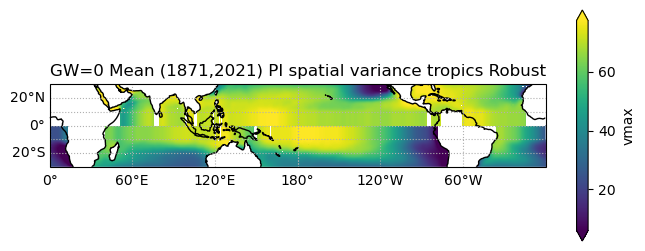

In [31]:
'''
summary: mean of all years, all months
'''

everything = dict_PI.values()
plot_xrda(xr.concat(everything, dim="time").mean(dim="time"), f"GW={GW} Mean (1871,2021) {parameter} {basin2mask} Robust", 1)

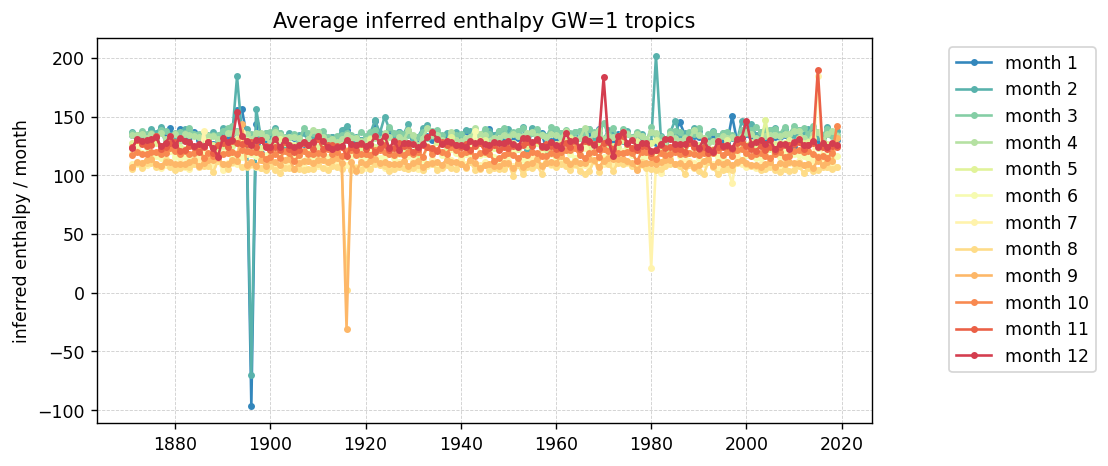

In [190]:
'''
most relevant to PI~
cross-section monthly split: one month at a time of all years
'''

number_of_samples = 12
colormap_name = 'Spectral_r'
yr_colors = get_colormap_samples(number_of_samples, colormap_name)


fig, ax = plt.subplots(figsize=(8,4), dpi=125)

for month in range(1,13):
    plot_title = f"Average {parameter} GW={GW} {basin2mask}"
    
    #month = 6
    collect_m = []
    avgs = []
    for yr in dict_PI.keys():
        if GW == 0:
            time_str = dict_PI0[yr].isel(time=i)['time'].item().strftime('%Y-%m-%d %H:%M:%S')
        elif GW == 1:
            time_str = dict_PI1[yr].isel(time=i)['time'].astype(str).item()[:10]
    
        avg = dict_PI[yr].isel(time=month-1).mean().item()
    
        avgs.append(avg)
        collect_m.append(dict_PI[yr].isel(time=month-1))
        #print(f"{yr}: {avg}")
        #plot_xrda(dict_PI0[yr].isel(time=month-1), f"GW={GW} PI {yr} {basin2mask} {time_str}",1) # plot month
        
    month_PI = xr.concat(collect_m, dim="time")
    #plot_xrda(month_PI.mean(dim="time"), f"{plot_title} Month {month}", 1, vmin=vmin, vmax=vmax)
    
    
    # timeplot
    ax.plot(dict_PI.keys(), avgs, color=yr_colors[month-1], marker="o", markersize=3, label=f"month {month}")    

ax.set_title(plot_title)
ax.set_ylabel(f"{parameter} / month")
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1))
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

In [ ]:
'''
over time
yearly split: one year at a time
'''

avgs = []
for yr in dict_PI.keys():
    #print(f"{yr}: {dict_PI[yr].mean(dim='time').mean().item()}")
    avgs.append(dict_PI[yr].mean(dim="time").mean())
    #plot_xrda(dict_PI[yr].mean(dim="time"), f"GW={GW} Mean PI {yr} {basin2mask}", 1)

# timeplot
fig, ax = plt.subplots(figsize=(8,4), dpi=125)
ax.plot(dict_PI.keys(), avgs, marker="o", markersize=3)    
ax.set_title(plot_title)
ax.set_ylabel(f"{parameter} / month")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

#### TC weighted PI

In [ ]:
# get experiment names and dictionary of xarrays
from pathlib import Path

experiment_path = 'EXPERIMENT_PATH'

experiments = []
if GW == 1:
    target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
    for file in target_files:
        experiments.append(str(file)[-29:])
    dictxr = dict_PI1
elif GW == 0:
    target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
    for file in target_files:
        experiments.append(str(file)[-39:])
    dictxr = dict_PI0

print(experiments)

['amipHadISSTlong_chancorr_rmWarming-en10', 'amipHadISSTlong_chancorr_rmWarming-en07', 'amipHadISSTlong_chancorr_rmWarming-en08', 'amipHadISSTlong_chancorr_rmWarming-en06', 'amipHadISSTlong_chancorr_rmWarming-en09']


In [21]:
# get mean of all xarrays in dictionary
xrlist = []

#for value in dictxr.values():
for value in dict_PI.values():
    xrlist.append(value)
concat_da = xr.concat(xrlist, dim='time')

# experiments already gathered in prev cell
model_name = 'AM2.5C360'
year_range = [1871, 2019]
PIx_da = concat_da.mean(dim="time")
experiment_name = experiments
    #en06-en10 (experiments[1-2, 5-7]) do not work for some reason -> all GW = 0

# return dictionary[model_name][experiment_name] of TC density
TCdensity = TC_analysis.TC_density(model_names=model_name, experiment_names=experiment_name, year_range=year_range)

listof_TCdensities = []

# combine all ensemble density outputs
for exp in experiment_name:
    TMP = TCdensity[model_name][exp]
    
    # convert dictionary to dataframe with same dims for xarray
    TCdensity_xr = xr.DataArray(data=TMP.values,
                                   coords={'lat': (['lat'], TMP.index),
                                           'lon': (['lon'], TMP.columns)},
                                   dims=['lat', 'lon'])
    
    TCdensity_xr = TCdensity_xr.sel(lat=slice(PIx_da.lat.min(), PIx_da.lat.max()))
    # Interpolate to GCM native resolution
    TCdensity_xr = TCdensity_xr.interp(lon=PIx_da.lon, lat=PIx_da.lat).fillna(0)
    listof_TCdensities.append(TCdensity_xr) # append xarray to list for concatenation

TCdensity_xr = xr.concat(listof_TCdensities, dim='time')

normDensity = ((TCdensity_xr - TCdensity_xr.min()) / (TCdensity_xr.max() - TCdensity_xr.min())) #normalize (0,1) for matrix multiplication
normDensity1 = normDensity+1 #normalize (1,2) for matrix multiplication

[TC_density()]: model name: AM2.5C360, experiment name: amipHadISSTlong_chancorr_rmWarming-en10, year range: [1871, 2019], month range: (1, 13), storm type: TS
[TC_density()]: model name: AM2.5C360, experiment name: amipHadISSTlong_chancorr_rmWarming-en07, year range: [1871, 2019], month range: (1, 13), storm type: TS
[TC_density()]: model name: AM2.5C360, experiment name: amipHadISSTlong_chancorr_rmWarming-en08, year range: [1871, 2019], month range: (1, 13), storm type: TS
[TC_density()]: model name: AM2.5C360, experiment name: amipHadISSTlong_chancorr_rmWarming-en06, year range: [1871, 2019], month range: (1, 13), storm type: TS
[TC_density()]: model name: AM2.5C360, experiment name: amipHadISSTlong_chancorr_rmWarming-en09, year range: [1871, 2019], month range: (1, 13), storm type: TS


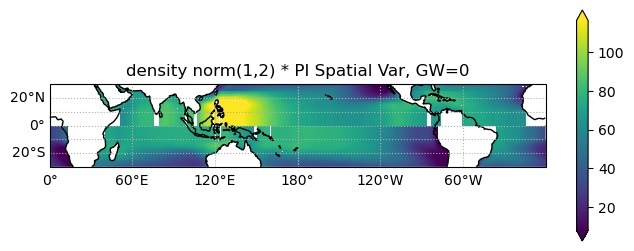

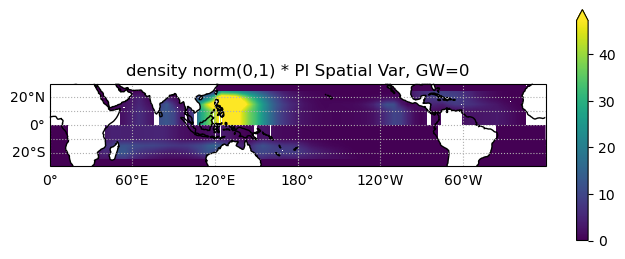

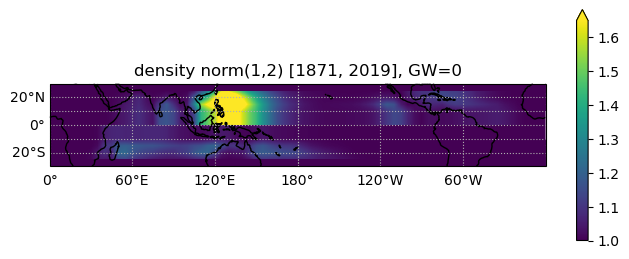

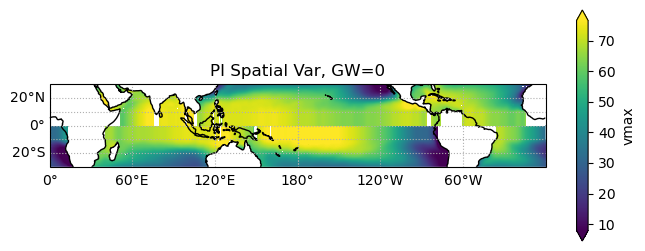

In [23]:
# plots
plot_xrda((normDensity1 * PIx_da).mean(dim="time"), f"density norm(1,2) * {parameter}, GW={GW}", 1)
plot_xrda((normDensity * PIx_da).mean(dim="time"), f"density norm(0,1) * {parameter}, GW={GW}", 1)
plot_xrda(normDensity1.mean(dim="time"), f"density norm(1,2) {year_range}, GW={GW}", 1)
plot_xrda(PIx_da, f"{parameter}, GW={GW}", 1)

### efficiency analysis
efficacy r = actual intensity / vmax aka PI

In [ ]:
def xr_filter_basin(basin2mask, xarray_ds):
    # get basin_ds
    basinmask_path = "BASIN_MASK_PATH"
    basin_ds = xr.open_dataset(basinmask_path).load()
    
    # apply latitude filter to datasets
    if basin2mask == 'tropics':
        xarray_ds = xr.concat([filtered_ds.sel(grid_yt=slice(-30,-10)), filtered_ds.sel(grid_yt=slice(10,30))], dim="grid_yt")
    elif basin2mask != 'global':
        # basin filter
        x = basin_ds.where(basin_ds[basin2mask] == 1, drop=True)[basin2mask] #stores basin coordinates

        maxlat = max(x['grid_yt']).item()
        minlat = min(x['grid_yt']).item()
        maxlon = max(x['grid_xt']).item()
        minlon = min(x['grid_xt']).item()
        
        xarray_ds = xarray_ds.where((xarray_ds['grid_yt'] >= minlat) & (xarray_ds['grid_yt'] <= maxlat), drop=True) #filter latitude
        xarray_ds = xarray_ds.where((xarray_ds['grid_xt'] >= minlon) & (xarray_ds['grid_xt'] <= maxlon), drop=True) #filter longitude
    
    return xarray_ds

In [ ]:
basinmask_path = "BASIN_MASK_PATH"
basin_ds = xr.open_dataset(basinmask_path).load()
basinmask_df = basin_ds.to_dataframe().reset_index()

def track_basin_filter(targetBasin, track_df):
    # basin boundaries
    lon_min = basinmask_df[basinmask_df[targetBasin] == 1]['grid_xt'].min()
    lon_max = basinmask_df[basinmask_df[targetBasin] == 1]['grid_xt'].max()
    lat_min = basinmask_df[basinmask_df[targetBasin] == 1]['grid_yt'].min()
    lat_max = basinmask_df[basinmask_df[targetBasin] == 1]['grid_yt'].max()

    # filter basin
    track_df = track_df[(track_df['center_lon'] >= lon_min) & (track_df['center_lon'] <= lon_max)] # filter by longitude
    track_df = track_df[(track_df['center_lat'] >= lat_min) & (track_df['center_lat'] <= lat_max)] # filter by latitude

    return track_df

#### generalized parameter LMI efficiency

In [21]:
# process LMI PI within each year
GW = 1 # set model
basin2mask = 'global'
interp = 1
climVar = 'vmax' # change 39, 44


decades = np.arange(1871, 2021, 10)
yearranges = [np.arange(year, year+10) for year in decades] #15 total decades

if GW == 1:
    fenum = 9
    pathS = forcing_SSTs['GW']
elif GW == 0:
    fenum = 11
    pathS = forcing_SSTs['NW']

ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)] # test one ennum for now

collect_LMIdfs = []
for decade in yearranges:
    st_time = time.time()
    print(f"decade: {decade}")
    #print(f"start time: {st_time}")

    collect_fds = [] # store vmax data
    collect_dec_LMIdfs = [] # collect only LMI rows of track_df for each decade

    # get decade track data
    decade_start = decade[0]
    track_df = track_TCs.get_trackdf(GW, decade_start)
    track_df = track_basin_filter(basin2mask, track_df)
    
    for year in decade:
        if year == 2020 and GW == 1: # no vmax data for this year
            continue
            
        # get year vmax data
        for ennum in ennums:
            To_pathname, VI_pathname = PIpathname(GW, ennum, year, climVar)
            collect_fds.append(xr.open_dataset(To_pathname)) # change parameter here
    
    # get decade vmax data
    filtered_ds = xr.concat(collect_fds, dim='time')
    filtered_ds = filtered_ds.groupby('time').mean(dim='time') # take mean value of all ensembles
    filtered_ds = xr_filter_basin(basin2mask, filtered_ds) # filter basin
    filtered_da = filtered_ds['vmax'] # change parameter
    filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"}) # rename coords to match

    # linearly interpolate vmax daily
    if interp == 1:
        daily_times = xr.date_range(start=filtered_da.isel(time=0)['time'].item(), end=filtered_da.isel(time=-1)['time'].item(), calendar='julian')
        filtered_da = filtered_da.interp(time=daily_times, method='linear') # interpolate
    
    # get decade LMI track data
    storm_ids = track_df['storm_id'].unique() # get all storm ids
    lmi_df = track_df.groupby('storm_id')['max_wind'].max().to_frame()

    
    # proccess LMI for this decade
    for i in storm_ids:
        #print(f"processing storm_id = {i}")
        LMIspeed = lmi_df.loc[i].item()
        storm_df = track_df.loc[(track_df['storm_id'] == i) & (track_df['max_wind'] == LMIspeed)]
        
        collect_dec_LMIdfs.append(storm_df)
    
    LMI_track_df = pd.concat(collect_dec_LMIdfs)
    #LMI_track_df = track_basin_filter(basin2mask, LMI_track_df)

    
    # adjust time for 19th & 20th century storms
    if decade[0] < 2000 and decade[0] >= 1900:
        offset_yrs = 100
    elif decade[0] < 1900 and decade[0] >= 1800:
        offset_yrs = 200
    else:
        offset_yrs = 0
    
    LMI_track_df['adj_time'] = [
        t - pd.DateOffset(years=100) if (t.year <= 2005 and 1900 in decade) else t if (t.year <= 2005 and 1999 in decade) else t - pd.DateOffset(years=offset_yrs) if (t.year not in decade) else t for t in LMI_track_df['time']
    ]

    # calculate r for this decade
    vmaxs = []
    for i, row in LMI_track_df.iterrows():
        t = row['adj_time']
        y = filtered_da.sel(lon=row['center_lon'], lat=row['center_lat'], method='nearest')
        y = y.sel(time=cftime.DatetimeJulian(year, t.month, t.day), method='nearest')
        
        vmaxs.append(y.item())
        #print(f"appended")
    
    LMI_track_df[climVar] = vmaxs
    LMI_track_df['r'] = LMI_track_df['max_wind']/LMI_track_df['vmax'] # calculate efficacy ratio r

    end_time = time.time()
    print(f"elapsed time: {end_time-st_time}")


    #LMI_track_df = LMI_track_df.drop(["time", "cftime"], axis=1)
    collect_LMIdfs.append(LMI_track_df)
    
Final_LMI_track_df = pd.concat(collect_LMIdfs)

# impose 2 filters for quality data
# 1. isolate for tropics
Final_LMI_track_df = Final_LMI_track_df[abs(Final_LMI_track_df['center_lat']) < 30]
# 2. minimum vmax threshold: 32.5 m/s to filter out weaker TCs
Final_LMI_track_df = Final_LMI_track_df[(Final_LMI_track_df[climVar]) >= 32.5]
# maybe: calculate r using potential intensity from X hours ago instead of current time

# add decade column for sns visualizations
Final_LMI_track_df['decade'] = (Final_LMI_track_df['adj_time'].dt.year // 10) * 10

Final_LMI_track_df

decade: [1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
elapsed time: 167.38710284233093
decade: [1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
elapsed time: 174.88671374320984
decade: [1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
elapsed time: 169.49230980873108
decade: [1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
elapsed time: 176.74750995635986
decade: [1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
elapsed time: 164.70311665534973
decade: [1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
elapsed time: 167.39727902412415
decade: [1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
elapsed time: 168.12912702560425
decade: [1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
elapsed time: 172.14626216888428
decade: [1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]
elapsed time: 172.36750054359436
decade: [1961 1962 1963 1964 1965 1966 1967 1968 1969 1970]
elapsed time: 168.1422188282013
decade: [1971 1972 1973 1974 1975 1976 1977 1978 1979 1980]
elapsed tim

,time,center_lon,center_lat,min_slp,max_wind,warm_core,storm_id,duration,cftime,adj_time,vmax,r,decade
10,2071-01-03 18:00:00,63.61,-25.23,976.00,39.02,259.92,0000-0000,12.25,0000-01-03 18:00:00,1871-01-03 18:00:00,60.032933,0.649977,1870
28,2071-01-03 00:00:00,135.45,16.84,973.55,34.96,263.26,0000-0001,10.25,0000-01-03 00:00:00,1871-01-03 00:00:00,69.740128,0.501290,1870
46,2071-01-15 00:00:00,112.90,8.96,979.62,28.06,260.90,0000-0002,10.25,0000-01-15 00:00:00,1871-01-15 00:00:00,63.641335,0.440908,1870
75,2071-01-19 18:00:00,106.44,-21.36,933.33,46.04,270.21,0000-0003,10.00,0000-01-19 18:00:00,1871-01-19 18:00:00,38.249199,1.203685,1870
102,2071-01-20 12:00:00,40.19,-28.09,991.79,28.19,259.56,0000-0004,7.25,0000-01-20 12:00:00,1871-01-20 12:00:00,67.888653,0.415239,1870
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233279,2020-12-03 12:00:00,120.17,9.44,963.91,48.43,270.14,0099-0067,12.25,0099-12-03 12:00:00,2020-12-03 12:00:00,73.091652,0.662593,2020
233314,2020-12-12 00:00:00,110.24,13.01,961.80,45.83,265.32,0099-0068,5.75,0099-12-12 00:00:00,2020-12-12 00:00:00,46.312183,0.989588,2020
233326,2020-12-14 12:00:00,129.56,12.26,943.91,53.09,270.83,0099-0069,10.50,0099-12-14 12:00:00,2020-12-14 12:00:00,73.015388,0.727107,2020
233349,2020-12-22 18:00:00,113.57,8.91,978.09,37.96,264.43,0099-0070,10.75,0099-12-22 18:00:00,2020-12-22 18:00:00,68.813393,0.551637,2020


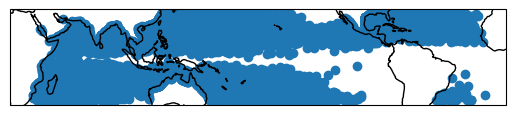

In [22]:
# plot coordinates
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

ax.scatter(Final_LMI_track_df['center_lon'], Final_LMI_track_df['center_lat'], transform=ccrs.PlateCarree())
ax.coastlines()

#### efficiency figures

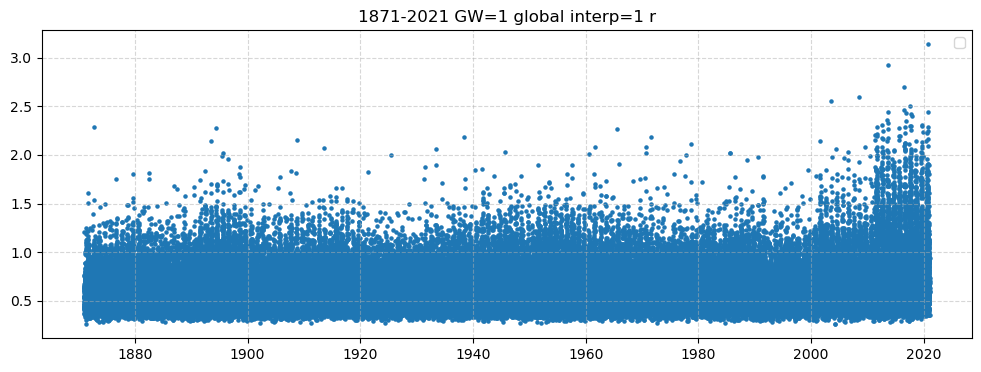

In [23]:
fig, ax = plt.subplots(figsize=(12,4))
ax.scatter(Final_LMI_track_df['adj_time'], Final_LMI_track_df['r'], marker="o", s=5)
ax.grid(linestyle='--', alpha=0.5, which='both')
ax.set_title(f"{decades[0]}-{decades[-1]+10} GW={GW} {basin2mask} interp={interp} r")
ax.legend()

Text(0, 0.5, 'r')

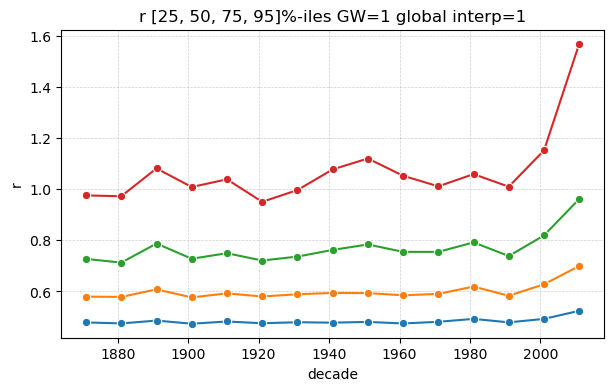

In [24]:
# percentile plots
pct = [25, 50, 75, 95] # specify desired percentile
stats = [] # store percentile stat

pct_names = [f"{percent}th" for percent in pct]
col_names = pct_names.copy()
col_names.append('decade')

decades = np.arange(1871, 2021, 10)

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms

for i in range(len(decades)):
    tempdict = {}
    tempdict['decade'] = decades[i]
    data = Final_LMI_track_df[Final_LMI_track_df['decade'] == decades[i]-1]['r']

    # calculate stat for vertical line
    percentiles = np.percentile(data, pct)
    for j in range(len(pct_names)):
        tempdict[col_names[j]] = percentiles[j]
    stats.append(tempdict)

stats_df = pd.DataFrame(stats)

# plot
for pth in pct_names:
    rg = np.ptp(stats_df[pth]) # find range
    sns.lineplot(data=stats_df, x='decade', y=pth, ax=ax, marker='o', label=f"{pth} range={round(rg,4)}", legend=False)
    
ax.set_title(f"r {pct}%-iles GW={GW} {basin2mask} interp={interp}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
#ax.legend()
ax.set_ylabel('r')

# standardize y axis across NW and GW
#ax.set_ylim([0.633, 0.643])

Text(0, 0.5, 'r')

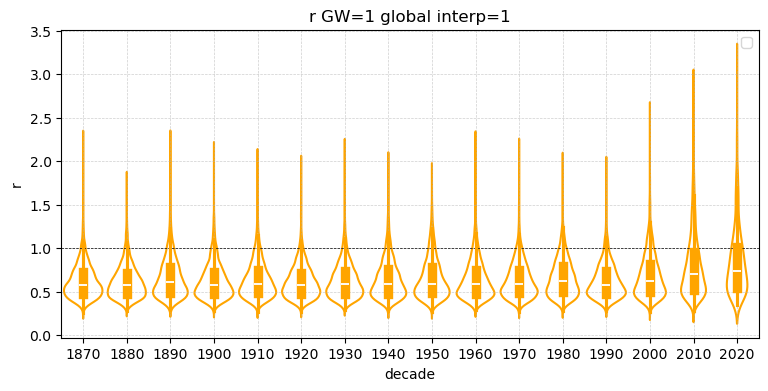

In [25]:
# violin plot
fig, ax = plt.subplots(figsize=(9,4))
ax.axhline(y=1, lw=0.5, c='black', linestyle='--') # theoretical threshold
sns.violinplot(data=Final_LMI_track_df, x="decade", y="r", color='orange', fill=False, ax=ax, width=0.9) # violin plots
ax.set_title(f"r GW={GW} {basin2mask} interp={interp}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()
ax.set_ylabel("r")

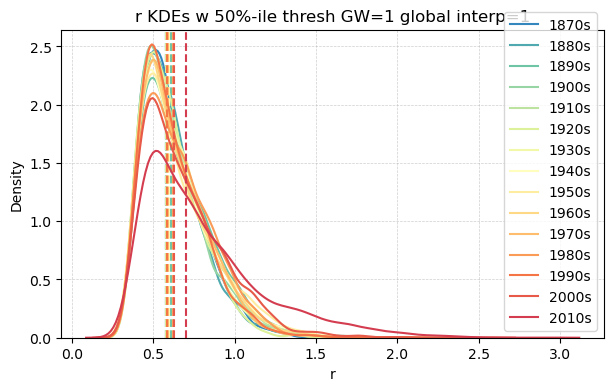

In [26]:
pct = 50 # specify desired percentile
stats = np.zeros(len(decades)) # store percentile stat
skews = np.zeros(len(decades)) # store skew

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms
for i in range(len(decades)):
    data = Final_LMI_track_df[Final_LMI_track_df['decade'] == decades[i]-1]['r']
    sns.kdeplot(data=data, cumulative=False, ax=ax, label=f"{decades[i]-1}s", color=colors[i])
    #ax.hist(yearPIs[(10*i):(10*i)+10], label=decades[i], color=colors[i])

    # measure skewness
    skews[i] = skew(np.array(data))
    
    # calculate stat for vertical line
    stats[i] = np.percentile(data, pct)
    ax.axvline(stats[i], color=colors[i], linestyle='--') # plot vertical line

ax.set_title(f"r KDEs w {pct}%-ile thresh GW={GW} {basin2mask} interp={interp}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()

### timeplot

In [23]:
parameter = 'Vmax'

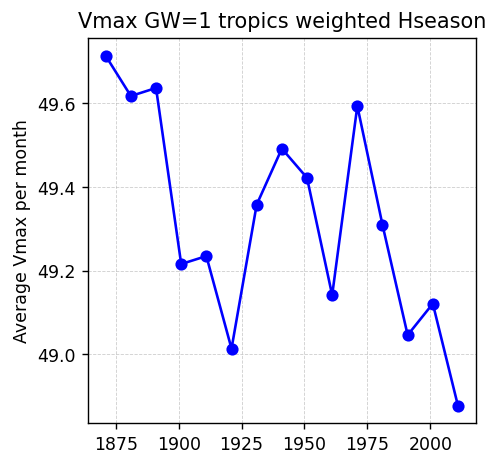

In [25]:
decades = np.arange(1871, 2021, 10)

fig, ax = plt.subplots(figsize=(4,4), dpi=125)
if GW == 1:
    ax.plot(decades, decade_means1, color='blue', marker="o", label=f"decade averages")
    #ax.plot(decades, manual_decmeans1, color='sienna', marker="o", label=f"avg of avgs")
elif GW == 0:
    ax.plot(decades, decade_means0, color='blue', marker="o", label=f"decade averages")
    #ax.plot(decades, manual_decmeans0, color='sienna', marker="o", label=f"avg of avgs")

ax.set_title(f"{parameter} GW={GW} {basin2mask} weighted Hseason")
ax.set_ylabel(f"Average {parameter} per month")
#ax.legend(loc='upper right', bbox_to_anchor=(1.5,1))
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

# standardize y axis across NW and GW
#ax.set_ylim([486, 502.5])

In [88]:
# GW=0 vs. GW=1 overlapped

# collect data
basin2mask = 'SP'
stat = 'mean'
climVar = 'chi_sb'
isWeighted = 1
inHSeason = 1

decades = np.arange(1871, 2021, 10)

dict_PI1, decade_means1, yearPI1 = get_manualPI(1, basin2mask, stat, climVar, isWeighted, inHSeason)
dict_PI0, decade_means0, yearPI0 = get_manualPI(0, basin2mask, stat, climVar, isWeighted, inHSeason)

GW=1 for chi_sb mean
decadal average weight=1 Hseason=1 PI: 
0.4920840068145447
time elapsed for [1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]: 28.654231786727905

decadal average weight=1 Hseason=1 PI: 
0.47372469510606424
time elapsed for [1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]: 15.622738122940063

decadal average weight=1 Hseason=1 PI: 
0.48094783155785875
time elapsed for [1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]: 15.090648651123047

decadal average weight=1 Hseason=1 PI: 
0.46344924108406343
time elapsed for [1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]: 15.284234523773193

decadal average weight=1 Hseason=1 PI: 
0.4690788388960915
time elapsed for [1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]: 15.3795804977417

decadal average weight=1 Hseason=1 PI: 
0.4713459800841447
time elapsed for [1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]: 15.210479736328125

decadal average weight=1 Hseason=1 PI: 
0.48925478669636446
time elapsed for [1931 1

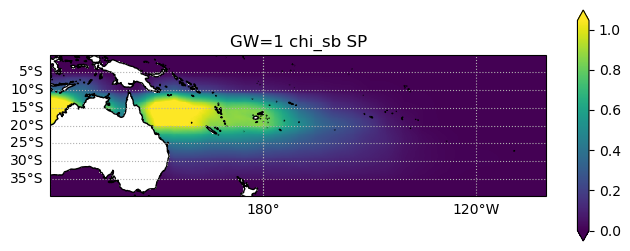

In [89]:
GW = 1
yr = 2004

# generalize dict variable
if GW == 0:
    dict_PI = dict_PI0
elif GW == 1:
    dict_PI = dict_PI1

plot_xrda(dict_PI[yr], f"GW={GW} {climVar} {basin2mask}", 1)

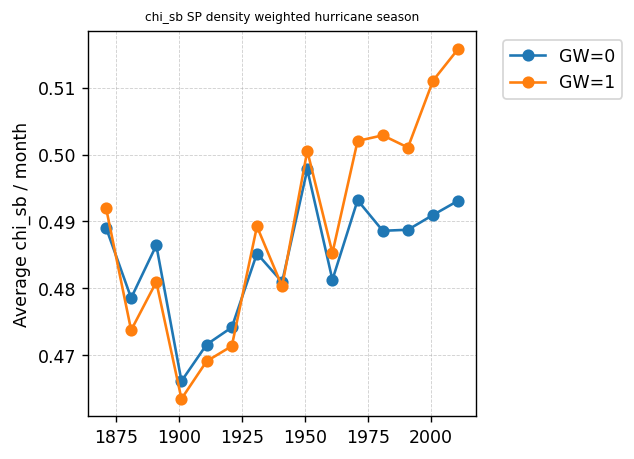

In [90]:
parameter = climVar

fig, ax = plt.subplots(figsize=(4,4), dpi=125)
ax.plot(decades, decade_means0, marker="o", label=f"GW=0")
ax.plot(decades, decade_means1, marker="o", label=f"GW=1")

ax.set_title(f"{parameter} {basin2mask} density weighted hurricane season", fontsize=7)
ax.set_ylabel(f"Average {parameter} / month")
ax.legend(loc='upper right', bbox_to_anchor=(1.4,1))
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

### TC variance map

'\nfor year in dict_PI:\n    xarray = dict_PI[year]\n    tempVar = xarray.var(dim=\'time\')\n    plot_xrda(tempVar, f"{year} PI temporal variance", 1, vmin=0, vmax=250)\n'

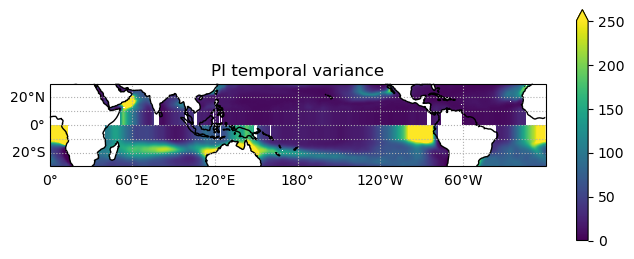

In [ ]:
# get dict_PI
GW = 0

if GW == 0:
    dict_PI = dict_PI0
elif GW == 1:
    dict_PI = dict_PI1

xarray = xr.concat(list(dict_PI.values()), dim="time")
tempVar = xarray.var(dim='time')
plot_xrda(tempVar, f"PI temporal variance", 1, vmin=0, vmax=250)

### PI histograms

In [59]:
if GW == 0:
    dict_PI = dict_PI0
    yearPIs = yearPI0
elif GW == 1:
    dict_PI = dict_PI1
    yearPIs = yearPI1

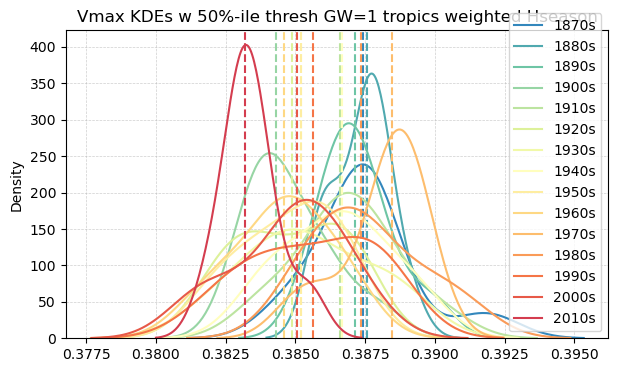

In [60]:
pct = 50 # specify desired percentile
stats = np.zeros(len(decades)) # store percentile stat
skews = np.zeros(len(decades)) # store skew

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms
for i in range(len(decades)):
    data = yearPIs[(10*i):(10*i)+10]
    sns.kdeplot(data=data, cumulative=False, ax=ax, label=f"{decades[i]-1}s", color=colors[i])
    #ax.hist(yearPIs[(10*i):(10*i)+10], label=decades[i], color=colors[i])

    # measure skewness
    skews[i] = skew(np.array(data))
    
    # calculate stat for vertical line
    stats[i] = np.percentile(data, pct)
    ax.axvline(stats[i], color=colors[i], linestyle='--') # plot vertical line

ax.set_title(f"{parameter} KDEs w {pct}%-ile thresh GW={GW} {basin2mask} weighted Hseason")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()

Text(0, 0.5, 'PI_T')

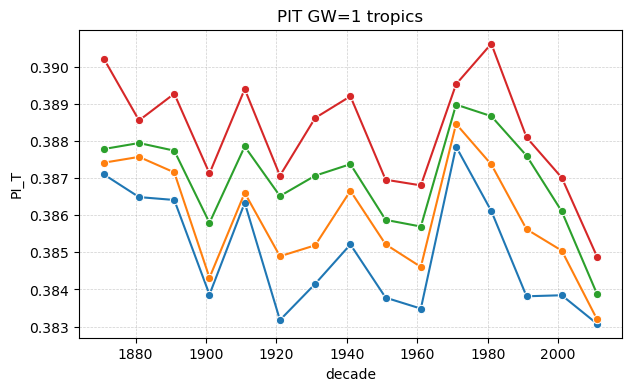

In [61]:
# multiple percentiles
pct = [25, 50, 75, 95] # specify desired percentile
stats = [] # store percentile stat

pct_names = [f"{percent}th" for percent in pct]
col_names = pct_names.copy()
col_names.append('decade')

decades = np.arange(1871, 2021, 10)

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms

for i in range(len(decades)):
    tempdict = {}
    tempdict['decade'] = decades[i]
    data = yearPIs[(10*i):(10*i)+10]

    # calculate stat for vertical line
    percentiles = np.percentile(data, pct)
    for j in range(len(pct_names)):
        tempdict[col_names[j]] = percentiles[j]
    stats.append(tempdict)

stats_df = pd.DataFrame(stats)

# plot
for pth in pct_names:
    rg = np.ptp(stats_df[pth]) # find range
    sns.lineplot(data=stats_df, x='decade', y=pth, ax=ax, marker='o', label=f"{pth} range={round(rg,4)}", legend=False)
    
ax.set_title(f"{climVar} GW={GW} {basin2mask}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
#ax.legend()
ax.set_ylabel("PI_T")

# standardize y axis across NW and GW
#ax.set_ylim([420, 520])

Text(0, 0.5, 'PI_T')

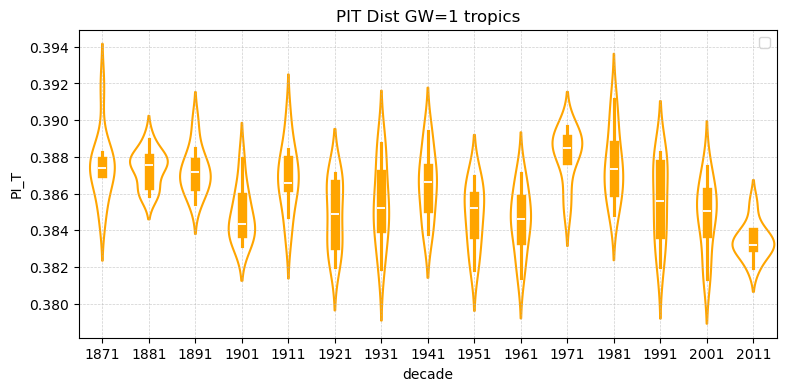

In [63]:
# violin plots
list_dict = [] # list to convert into dataframe

# collect data
for i in range(len(decades)):
    data = yearPIs[(10*i):(10*i)+10]

    for point in data:
        tempdict = {}
        tempdict['decade'] = decades[i]
        tempdict['PI'] = point
        list_dict.append(tempdict)

stats_df = pd.DataFrame(list_dict)

# plot
fig, ax = plt.subplots(figsize=(9,4))
sns.violinplot(data=stats_df, x="decade", y="PI", color='orange', fill=False, ax=ax, width=0.9) # violin plots
ax.set_title(f"{climVar} Dist GW={GW} {basin2mask}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()
ax.set_ylabel("PI_T")

# standardize y axis across NW and GW
#ax.set_ylim([375, 600])